# Analysis of the Fitness score of from the evolutions

## Setup

In [2]:
# Imports

import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

slurm_job = 15714478

result_dir = result_dir + str(slurm_job) + "/"

Plotting the evolution of the fitness function of the runs that resulted in interesting behaviour.

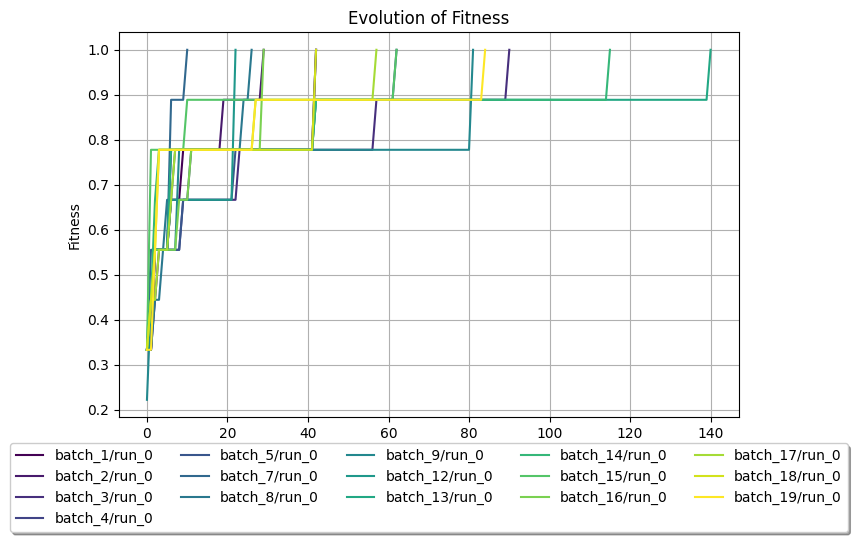

In [3]:
runs = [0]
batches = [1,2,3,4,5,7,8,9,12,13,14,15,16,17,18,19]

plt.figure(figsize=(8,5))

colors = plt.cm.viridis(np.linspace(0, 1, len(runs)*len(batches)))
counter = 0

for batch in batches:
    for run in runs:
        overall_evolution_dir = result_dir + "batch_"+str(batch)+"/run_"+str(run)+"/evol_" + str(run) + ".dat"
        # pass the input
        df = pd.read_csv(
            overall_evolution_dir,
            sep=r"\s+",
            header=None,
            names=["generation", "best_fitness", "avg_fitness"]
        )

        generation = df["generation"].to_numpy()
        best = df["best_fitness"].to_numpy()
        average = df["avg_fitness"].to_numpy()

        label_name = "batch_" + str(batch)+"/run_"+str(run)

        plt.plot(generation, best, 
                linestyle="-", 
                label=label_name,
                color=colors[counter],
            )

        counter += 1

plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Evolution of Fitness")

# Put a legend below current axis
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)
plt.grid(True)

plt.show()
    

same plot of evolution, but they are now split into groups (the same as chunk size)

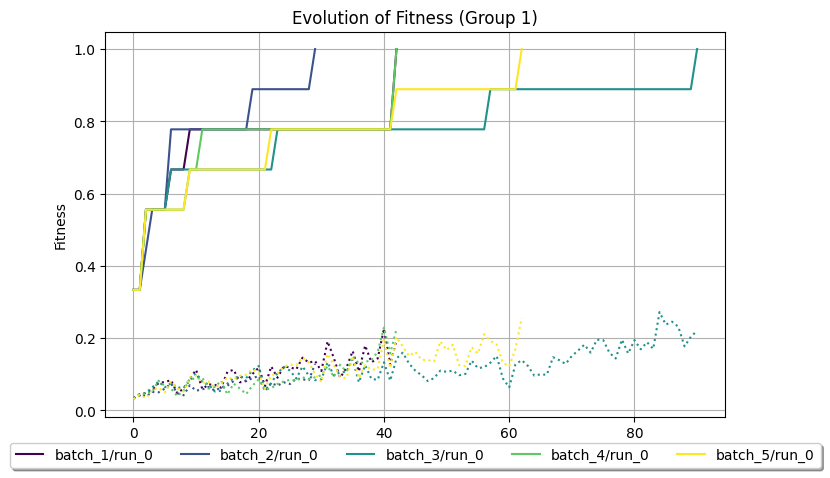

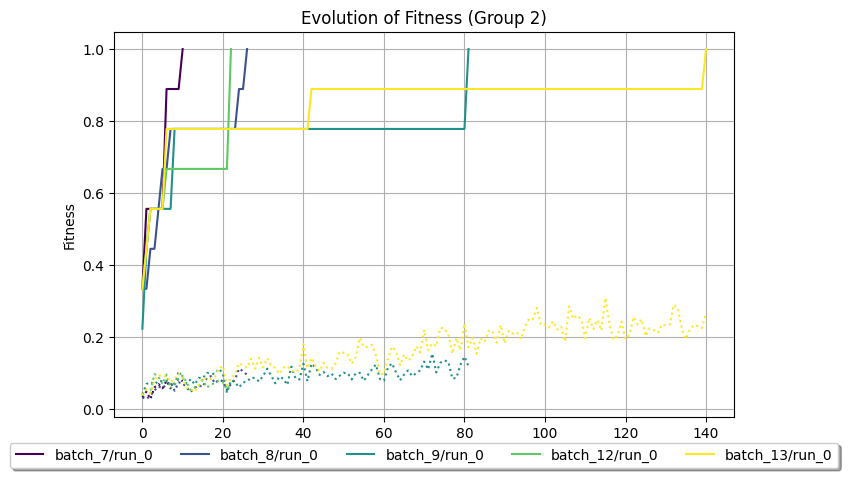

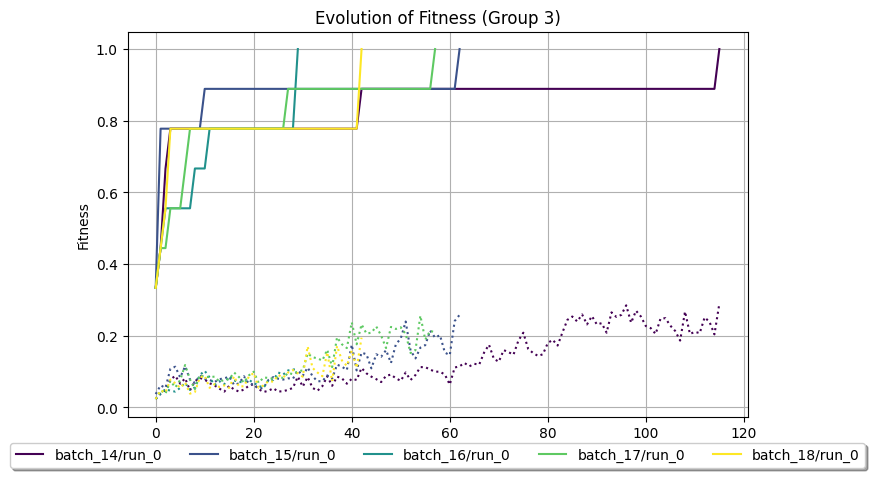

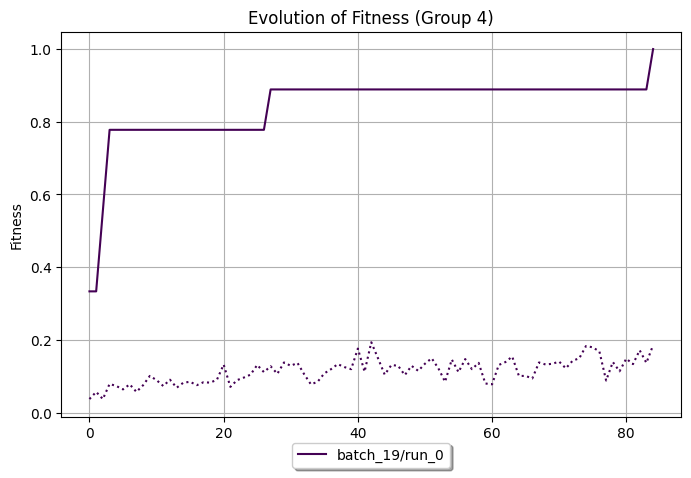

In [4]:
runs = [0]
batches = [1,2,3,4,5,7,8,9,12,13,14,15,16,17,18,19]

chunk_size = 5

# Split batches into chunks of 5
batch_groups = [batches[i:i+chunk_size] for i in range(0, len(batches), chunk_size)]
for group_idx, batch_group in enumerate(batch_groups):
    plt.figure(figsize=(8,5))
    colors = plt.cm.viridis(np.linspace(0, 1, len(batch_group)*len(runs)))
    counter = 0

    for batch in batch_group:
        for run in runs:
            overall_evolution_dir = result_dir + "batch_"+str(batch)+"/run_"+str(run)+"/evol_" + str(run) + ".dat"
            # pass the input
            df = pd.read_csv(
                overall_evolution_dir,
                sep=r"\s+",
                header=None,
                names=["generation", "best_fitness", "avg_fitness"]
            )

            generation = df["generation"].to_numpy()
            best = df["best_fitness"].to_numpy()
            average = df["avg_fitness"].to_numpy()

            label_name = "batch_" + str(batch)+"/run_"+str(run)

            plt.plot(generation, best, 
                    linestyle="-", 
                    label=label_name,
                    color=colors[counter],
                )

            plt.plot(generation, average, 
                    linestyle=":", 
                    color=colors[counter],
                )
            counter += 1

    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.title(f"Evolution of Fitness (Group {group_idx+1})")
    # Put a legend below current axis
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
            fancybox=True, shadow=True, ncol=5)
    plt.grid(True)

    plt.show()
    